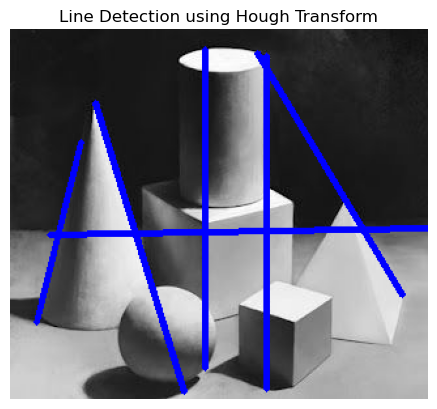

In [7]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Read image
img = cv2.imread('shape.jpg', cv2.IMREAD_COLOR)  # Replace 'shape.jpg' with your image path

# Convert the image to grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Find the edges in the image using Canny detector
edges = cv2.Canny(gray, 50, 200)

# Detect points that form a line using Hough Transform
lines = cv2.HoughLinesP(edges, 1, np.pi / 180, 68, minLineLength=15, maxLineGap=250)

# Draw lines on the image
for line in lines:
    x1, y1, x2, y2 = line[0]
    cv2.line(img, (x1, y1), (x2, y2), (255, 0, 0), 3)

# Convert the image to RGB for proper display in matplotlib
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Display the result using matplotlib
plt.imshow(img_rgb)
plt.axis('off')  # Hide the axes
plt.title("Line Detection using Hough Transform")
plt.show()


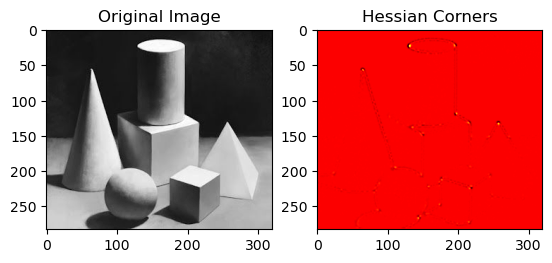

In [32]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load and blur the image
img = cv2.imread('shape.jpg', cv2.IMREAD_GRAYSCALE)
blurred = cv2.GaussianBlur(img, (5, 5), 0)

# Compute second-order derivatives using Sobel
Ix = cv2.Sobel(blurred, cv2.CV_64F, 1, 0, ksize=3)
Iy = cv2.Sobel(blurred, cv2.CV_64F, 0, 1, ksize=3)
Ixx = cv2.Sobel(Ix, cv2.CV_64F, 1, 0, ksize=3)
Iyy = cv2.Sobel(Iy, cv2.CV_64F, 0, 1, ksize=3)
Ixy = cv2.Sobel(Ix, cv2.CV_64F, 0, 1, ksize=3)

# Compute Hessian matrix response
det_H = Ixx * Iyy - Ixy * Ixy
trace_H = Ixx + Iyy
corner_response = det_H - 0.04 * (trace_H ** 2)

# Reduce the threshold even further to detect more corners
corner_response = np.uint8(cv2.normalize(corner_response, None, 0, 255, cv2.NORM_MINMAX))

# Set the threshold even lower for more sensitivity
threshold = 0.001 * corner_response.max()  # Very low threshold for maximum sensitivity
corner_response[corner_response < threshold] = 0

# Display results
plt.subplot(1, 2, 1), plt.imshow(img, cmap='gray'), plt.title('Original Image')
plt.subplot(1, 2, 2), plt.imshow(corner_response, cmap='hot'), plt.title('Hessian Corners')
plt.show()


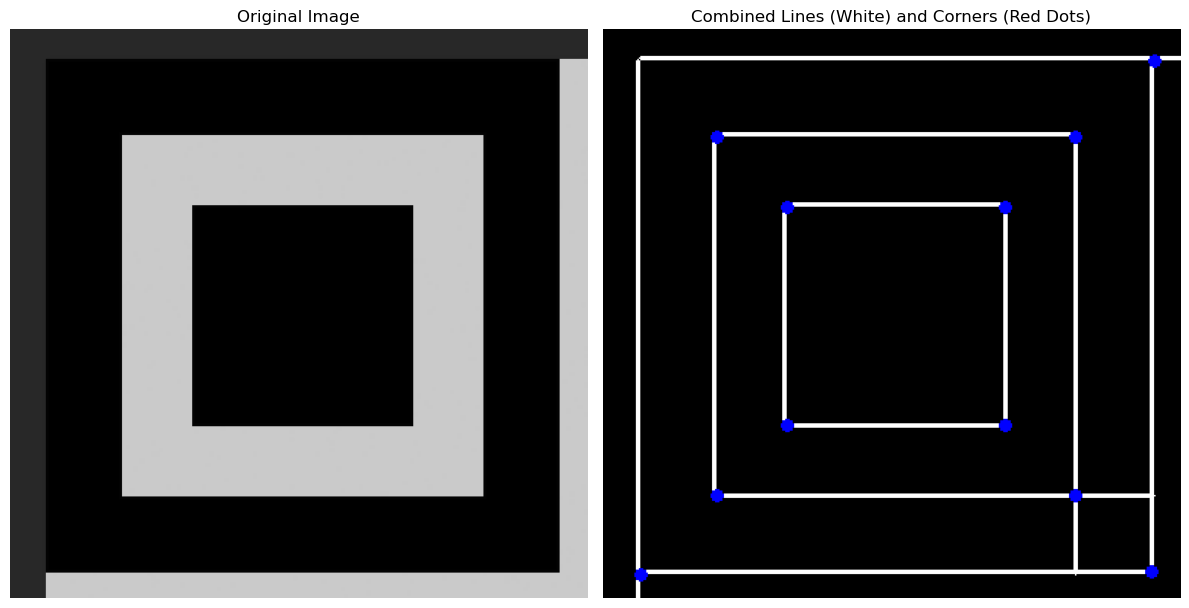

In [80]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load the image in grayscale
img = cv2.imread('box.png', cv2.IMREAD_GRAYSCALE)

# Check if the image was loaded successfully
if img is None:
    print("Error: Image not loaded. Check the file path.")
else:
    # ----------- Line Detection using Hough Transform -----------
    # Apply Canny Edge detector
    edges = cv2.Canny(img, 50, 150)

    # Detect lines using Hough Transform
    lines = cv2.HoughLinesP(edges, 1, np.pi/180, 100, minLineLength=50, maxLineGap=250)

    # ----------- Corner Detection using Harris Corner Detection -----------
    # Apply Gaussian Blur to smooth the image and reduce noise
    blurred = cv2.GaussianBlur(img, (5, 5), 0)

    # Harris Corner detection
    dst = cv2.cornerHarris(blurred, 2, 3, 0.04)

    # Dilate the result to enhance the corner points
    dst = cv2.dilate(dst, None)

    # Normalize the Harris response for better visibility
    dst = cv2.normalize(dst, None, 0, 255, cv2.NORM_MINMAX)
    dst = np.uint8(dst)

    # Apply a threshold to identify corners (higher threshold will detect stronger corners)
    _, corner_response = cv2.threshold(dst, 150, 255, cv2.THRESH_BINARY)

    # ----------- Create a Color Image for Combination -----------
    # Create a color image (black background) for displaying combined lines and corners
    combined_img = np.zeros((img.shape[0], img.shape[1], 3), dtype=np.uint8)  # Black background (RGB format)

    # ----------- Draw Lines on the Combined Image -----------
    if lines is not None:
        for line in lines:
            x1, y1, x2, y2 = line[0]
            # Draw lines in white color (BGR format)
            cv2.line(combined_img, (x1, y1), (x2, y2), (255, 255, 255), 2)  # White lines

    # ----------- Highlight Corners as Red Dots -----------
    # Find corner points and mark them as small red circles
    corners = np.argwhere(corner_response == 255)  # Get the coordinates of the corners
    for corner in corners:
        y, x = corner
        # Draw a small red circle (BGR format) at each corner point
        cv2.circle(combined_img, (x, y), 3, (0, 0, 255), -1)  # Red circles

    # ----------- Display the Results -----------
    plt.figure(figsize=(12, 8))

    # Display original image
    plt.subplot(1, 2, 1)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB), cmap='gray')
    plt.title('Original Image')
    plt.axis('off')

    # Display combined image with lines in white and corners as red dots
    plt.subplot(1, 2, 2)
    plt.imshow(combined_img)
    plt.title('Combined Lines (White) and Corners (Red Dots)')
    plt.axis('off')

    plt.tight_layout()
    plt.show()


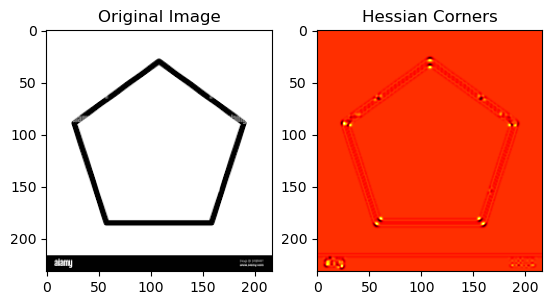

In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load and blur the image
img = cv2.imread('img.png', cv2.IMREAD_GRAYSCALE)
blurred = cv2.GaussianBlur(img, (5, 5), 0)

# Compute second-order derivatives using Sobel
Ix = cv2.Sobel(blurred, cv2.CV_64F, 1, 0, ksize=3)
Iy = cv2.Sobel(blurred, cv2.CV_64F, 0, 1, ksize=3)
Ixx = cv2.Sobel(Ix, cv2.CV_64F, 1, 0, ksize=3)
Iyy = cv2.Sobel(Iy, cv2.CV_64F, 0, 1, ksize=3)
Ixy = cv2.Sobel(Ix, cv2.CV_64F, 0, 1, ksize=3)

# Compute Hessian matrix response
det_H = Ixx * Iyy - Ixy * Ixy
trace_H = Ixx + Iyy
corner_response = det_H - 0.04 * (trace_H ** 2)

# Reduce the threshold even further to detect more corners
corner_response = np.uint8(cv2.normalize(corner_response, None, 0, 255, cv2.NORM_MINMAX))

# Set the threshold even lower for more sensitivity
threshold = 0.001 * corner_response.max()  # Very low threshold for maximum sensitivity
corner_response[corner_response < threshold] = 0

# Display results
plt.subplot(1, 2, 1), plt.imshow(img, cmap='gray'), plt.title('Original Image')
plt.subplot(1, 2, 2), plt.imshow(corner_response, cmap='hot'), plt.title('Hessian Corners')
plt.show()

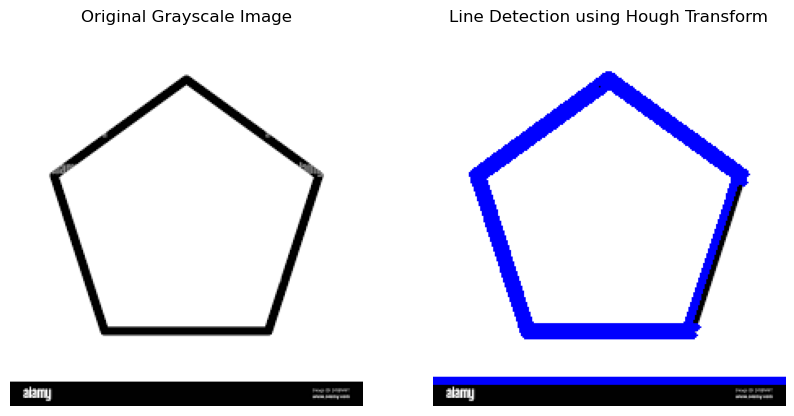

In [11]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Read image in grayscale
gray = cv2.imread('img.png', cv2.IMREAD_GRAYSCALE)  # Replace 'img.png' with your image path
original_img = gray.copy()  # Copy for display

# Find the edges in the image using Canny detector
edges = cv2.Canny(gray, 50, 200)

# Detect points that form a line using Hough Transform
lines = cv2.HoughLinesP(edges, 1, np.pi / 180, 68, minLineLength=15, maxLineGap=250)

# Convert grayscale image to BGR for drawing lines
img = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)

# Draw lines on the image
if lines is not None:
    for line in lines:
        x1, y1, x2, y2 = line[0]
        cv2.line(img, (x1, y1), (x2, y2), (255, 0, 0), 3)

# Convert the image to RGB for proper display in matplotlib
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Display original and modified images
plt.figure(figsize=(10, 5))

# Original grayscale image
plt.subplot(1, 2, 1)
plt.imshow(original_img, cmap='gray')
plt.axis('off')
plt.title("Original Grayscale Image")

# Processed image
plt.subplot(1, 2, 2)
plt.imshow(img_rgb)
plt.axis('off')
plt.title("Line Detection using Hough Transform")

plt.show()
